In [20]:
# Imports
from scipy import stats

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import statsmodels.api as sm

# Part 1: Data Collection and Preparation

In [21]:
tickers = ["AAPL", "NVDA", "AMZN", "GOOGL", "MSFT"]
start = "2022-01-01"
end = "2026-05-01"
interval = "1d"

In [22]:
# Data downloading and saving
# Close price is used because it is the most widely used in literature.
data = yf.download(tickers=tickers, start=start, end=end, interval=interval, auto_adjust=True)["Close"] # adjusted for splits and dividents
data.head(5)
data.to_csv("data/close_prices_full.csv")

In [23]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1085 entries, 2022-01-03 to 2026-04-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1085 non-null   float64
 1   AMZN    1085 non-null   float64
 2   GOOGL   1085 non-null   float64
 3   MSFT    1085 non-null   float64
 4   NVDA    1085 non-null   float64
dtypes: float64(5)
memory usage: 50.9 KB


After downloading data, the dataset contains 1003 trading days with no missing values

In [24]:
daily_returns = (data - data.shift(1)) /  data.shift(1)
daily_returns = daily_returns.dropna()

log_daily_returns = np.log(data / data.shift(1))
log_daily_returns = log_daily_returns.dropna()

# Save to csv for later usage
daily_returns.to_csv("data/daily_returns_full.csv")
log_daily_returns.to_csv("data/log_daily_returns_full.csv")

# Part 2: Descriptive Statistics

In [25]:
colors = {
    "AAPL": "#8E8E93",
    "NVDA": "#76B900",
    "AMZN": "#FF9900",
    "GOOGL": "#4285F4",
    "MSFT": "#F25022"
}

rolling_window = 25 # Month has 25 trading days

Plot 1: Price and its moving average

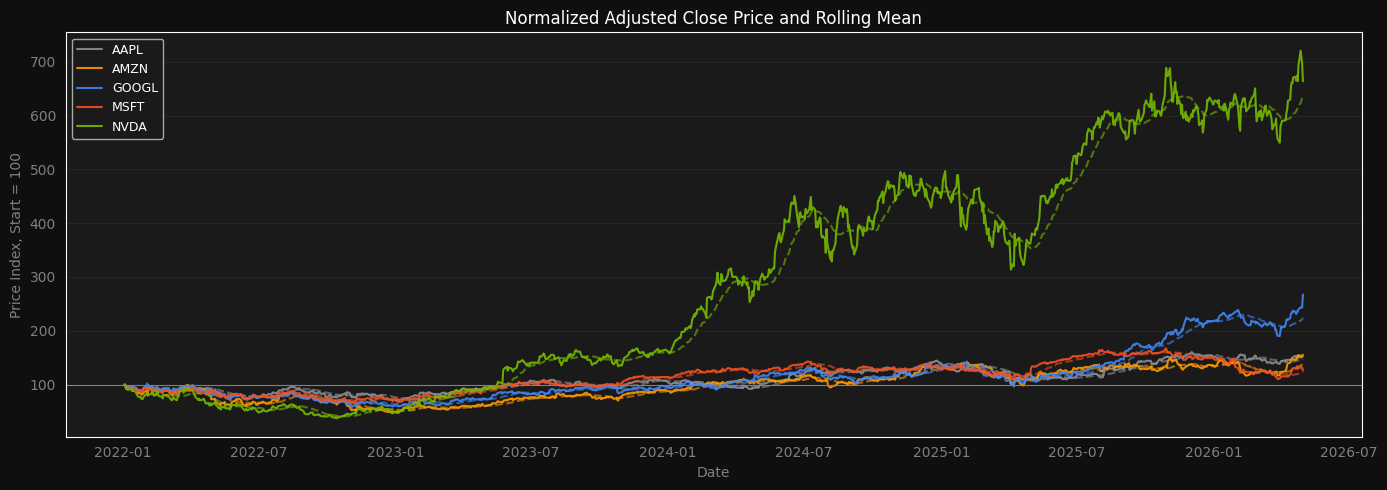

In [40]:
normalized_prices = data / data.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")
for ticker in normalized_prices.columns:
    ax.plot(normalized_prices.index, normalized_prices[ticker], color=colors[ticker], label=ticker, alpha=0.9)
    ax.plot(normalized_prices.index, normalized_prices[ticker].rolling(rolling_window).mean(), color=colors[ticker], linestyle="--", alpha=0.6)

ax.axhline(100, color="gray", linewidth=0.8)
ax.tick_params(colors="gray")
ax.set_title("Normalized Adjusted Close Price and Rolling Mean", color="white")
ax.set_ylabel("Price Index, Start = 100", color="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
ax.xaxis.grid(False)
ax.set_xlabel("Date", color="gray")
ax.legend(facecolor="#1A1A1A", labelcolor="white", framealpha=0.8, fontsize=9)
plt.tight_layout()

plt.savefig("plots/price_rolling_mean.png",facecolor=fig.get_facecolor())

Plot 2: Daily returns

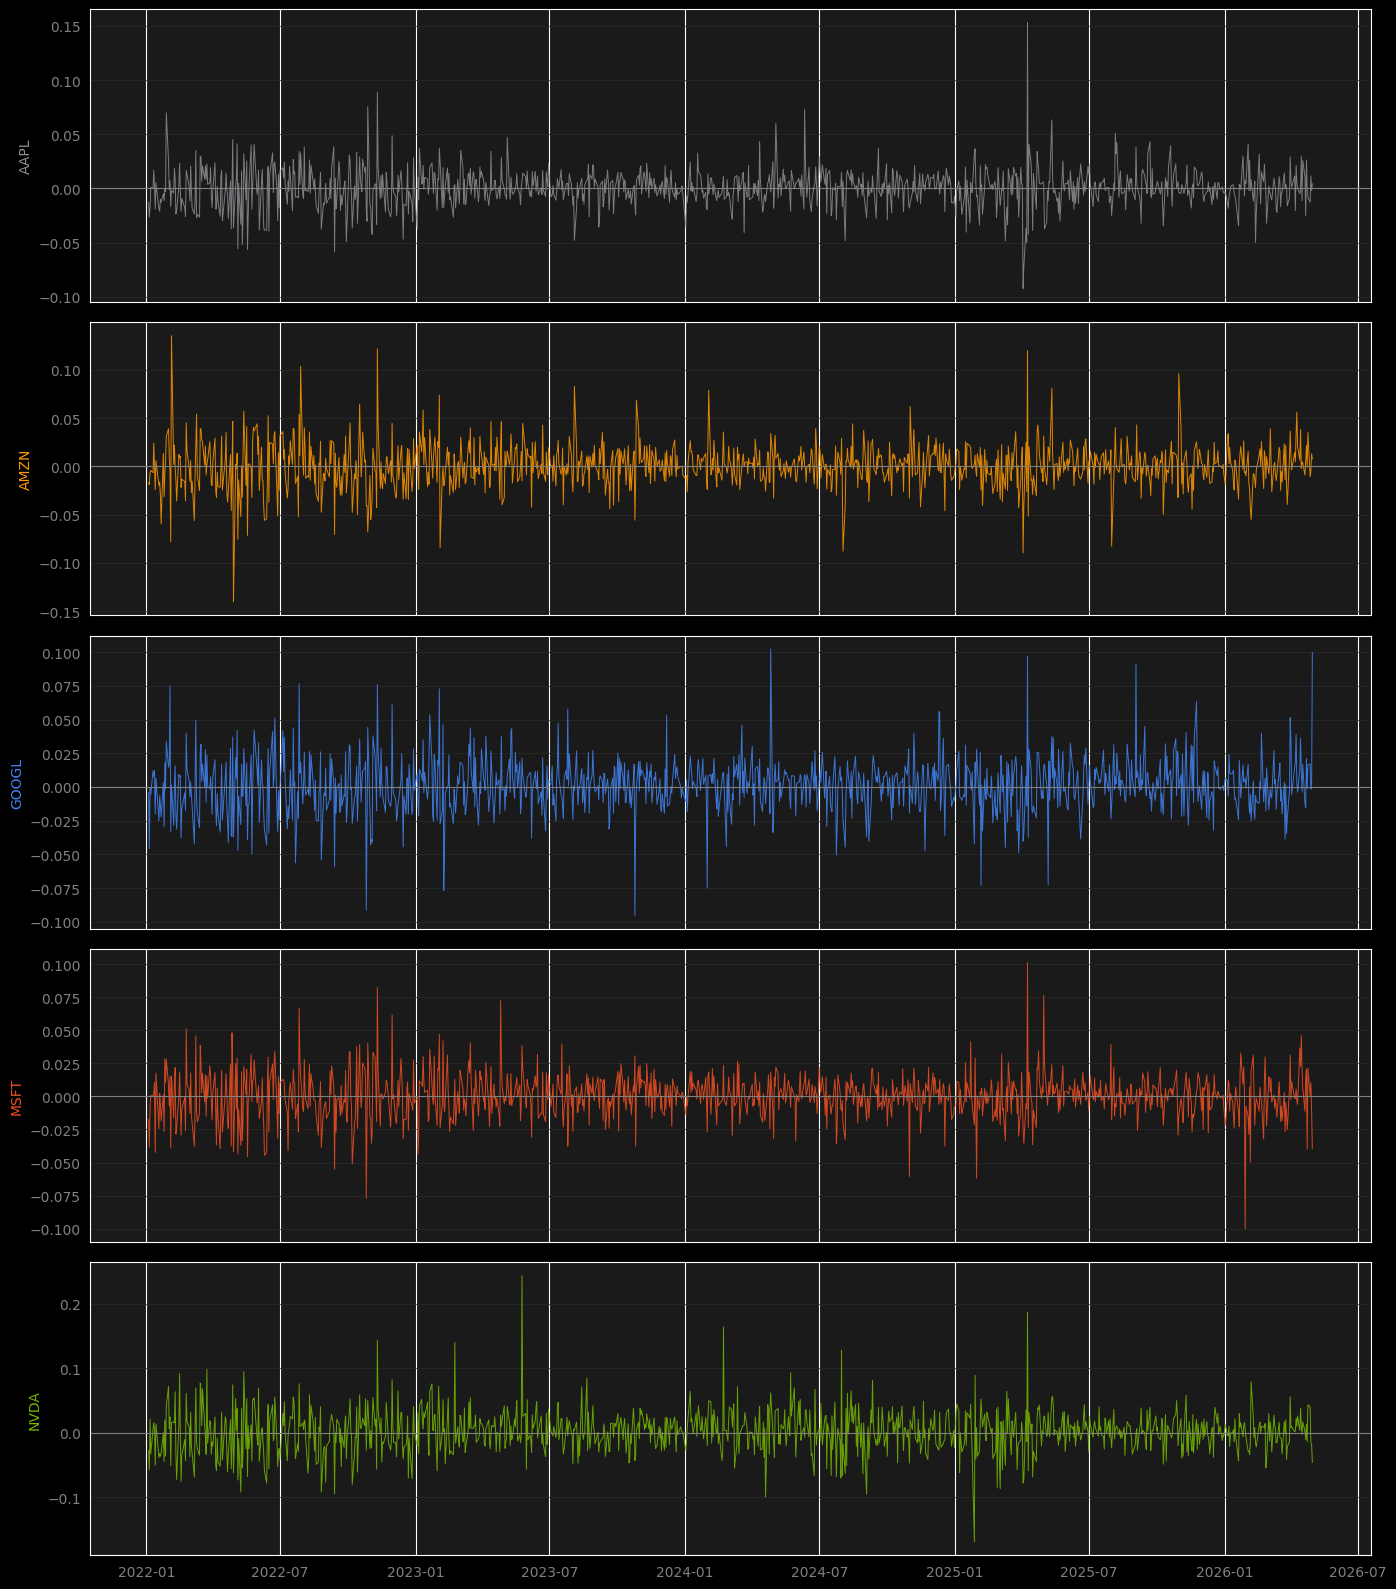

In [27]:
ig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True) # We plot with subplots, as all are centered near 0 and it is not possible to distinguish in one plot
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(daily_returns.index, daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/daily_returns.png",facecolor=fig.get_facecolor())
plt.show()


Plot 3: Log daily returns

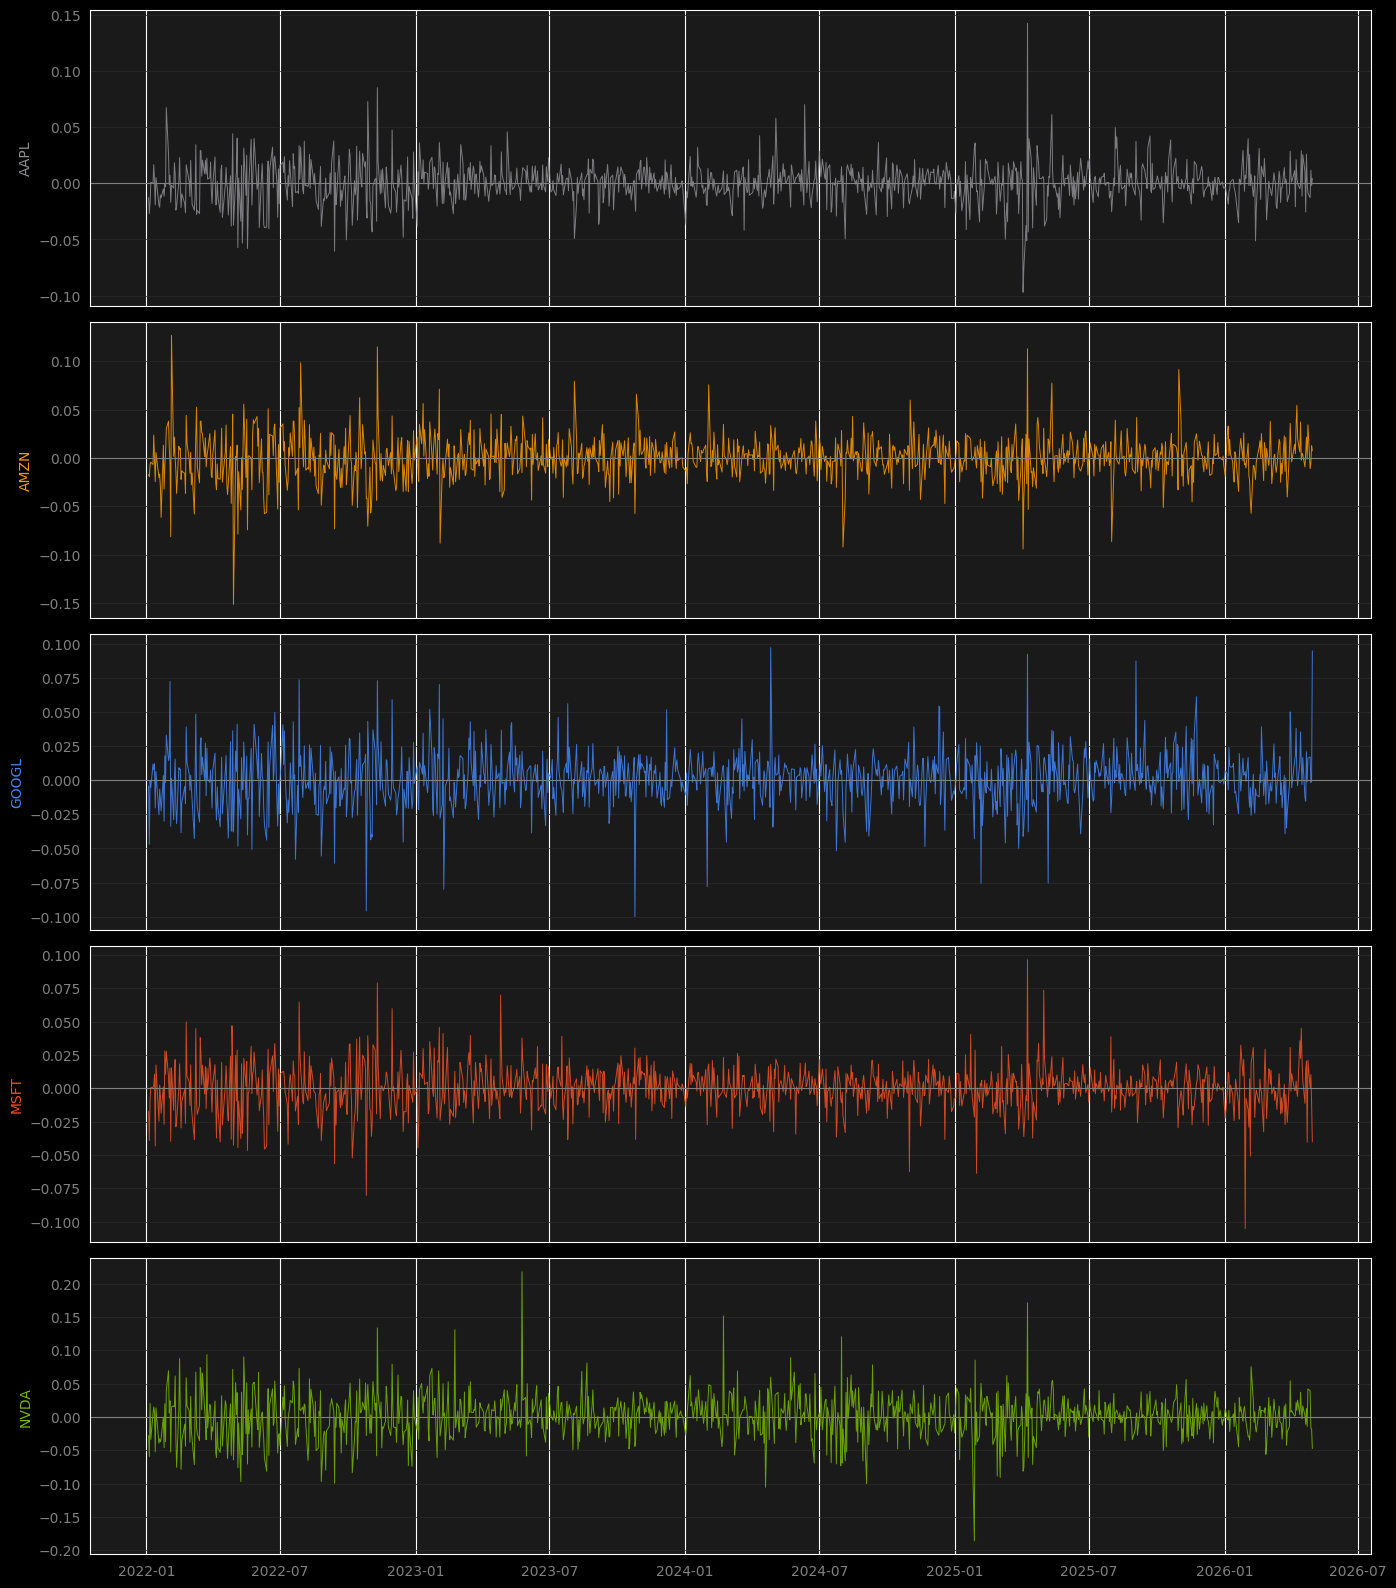

In [28]:
ig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Log Daily Returns", color="white", fontsize=14, y=1.01)

for ax, ticker in zip(axes, log_daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.plot(log_daily_returns.index, log_daily_returns[ticker], color=colors[ticker], linewidth=0.7, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/log_daily_returns.png",facecolor=fig.get_facecolor())
plt.show()

Nvidia share prices have been growing steadily during the period, manifestin the AI boom. Amazon, Google and Applve have followed a similar upward trend over time, with Google having the sharpest increase in share price from about `140$` in the beggining of 2022 to almost `400$` today. The swiftly changing rolling mean of Microsoft stock prices 2025 and 2026 is signaling about possible market dissatisfaction with investments in AI. All stock have characteristic volatility with Nvidia showing most drastic changes in returns. There are visible shocks in the market, like the plunge in prices of all stocks in mid 2025, presumably due to economic uncertainties in the market caused by US tariff policy changes.

In [29]:
# Statistics for daily returns

summary_daily = daily_returns.describe().T
summary_daily["skewness"] = daily_returns.skew()
summary_daily["kurtosis"] = daily_returns.kurt()

summary_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
AAPL,1084.0,0.000546,0.017790,-0.092456,-0.008180,0.000791,0.009307,0.153289,0.521539,7.189955
AMZN,1084.0,0.000679,0.023301,-0.140494,-0.012101,0.000612,0.013885,0.135359,0.152744,4.613261
GOOGL,1084.0,0.001118,0.020512,-0.095094,-0.010426,0.001235,0.012032,0.102243,0.180926,3.167928
MSFT,1084.0,0.000363,0.017221,-0.099932,-0.008168,0.000510,0.009806,0.101337,0.040417,3.763490
NVDA,1084.0,0.002294,0.033239,-0.169682,-0.016845,0.002892,0.020453,0.243696,0.541315,4.872263


In [30]:
# Statistics for daily log returns

summary_log_daily = log_daily_returns.describe().T
summary_log_daily["skewness"] = log_daily_returns.skew()
summary_log_daily["kurtosis"] = log_daily_returns.kurt()

summary_log_daily

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
AAPL,1084.0,0.000388,0.017722,-0.097013,-0.008214,0.000791,0.009264,0.142618,0.299714,6.117729
AMZN,1084.0,0.000408,0.023286,-0.151398,-0.012175,0.000612,0.013789,0.126949,-0.076263,4.603852
GOOGL,1084.0,0.000908,0.020474,-0.099924,-0.010481,0.001234,0.011960,0.097348,0.024625,3.093769
MSFT,1084.0,0.000215,0.017224,-0.105284,-0.008201,0.000510,0.009759,0.096525,-0.107480,3.753164
NVDA,1084.0,0.001746,0.032982,-0.185946,-0.016988,0.002888,0.020246,0.218088,0.238734,3.944839


Nvidia is simultaneously the most profitable and risky stock, with the highest mean and standard deviation. The least volatile stock are those of Apple and Microsoft. Nevertheless, Apple has a more favorable profitability, despite the fact that its returns have the heaviest tails. Google stocks, compared to those of Apple, Amazon and Microsoft, has much larger mean value with slightly worse volatility. However Google stock returns are the least skwed and thw closest to the bell-shaped structure.

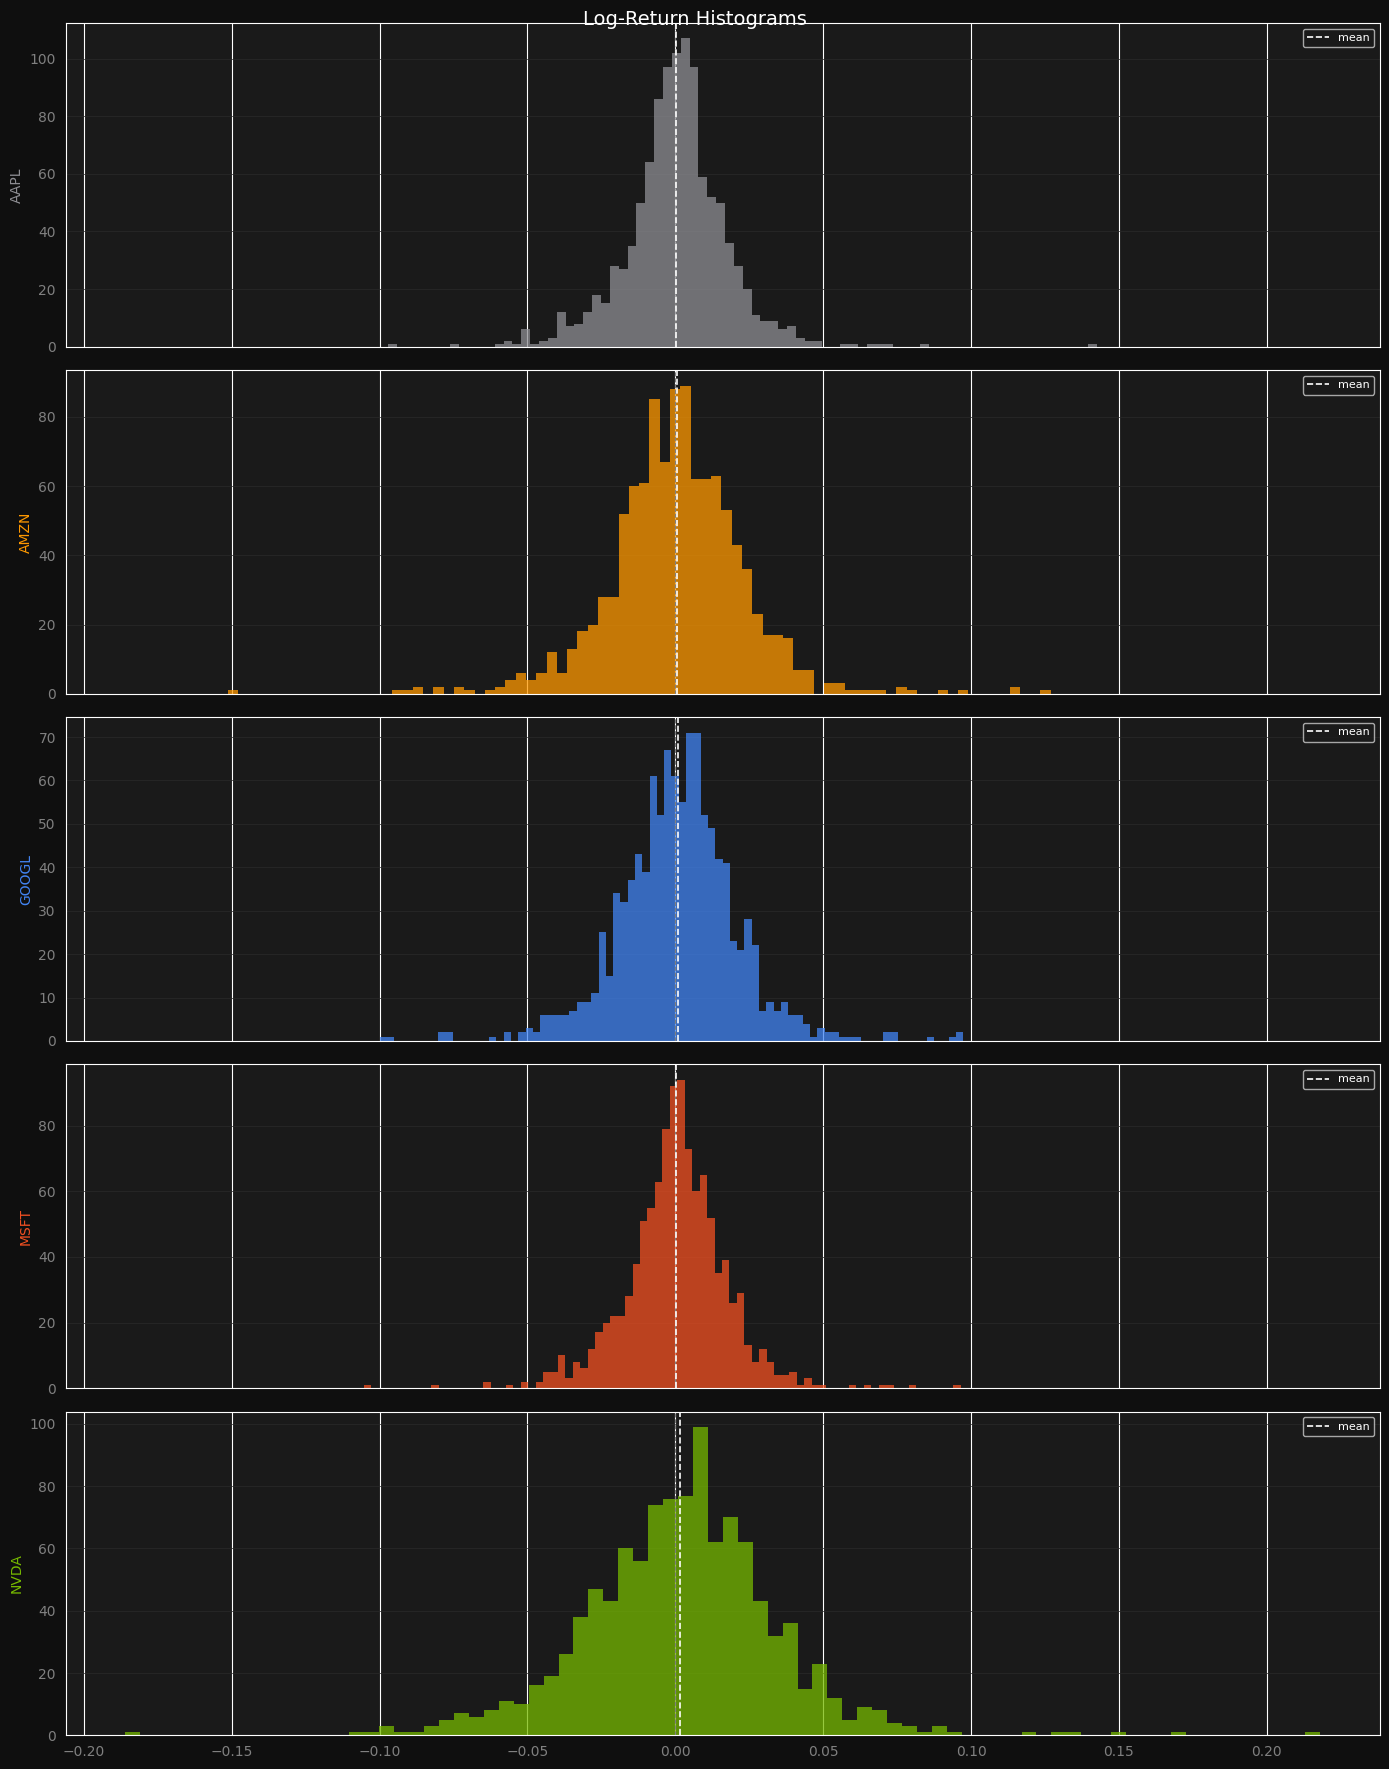

In [31]:
# Figure 1: Hystograms
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Log-Return Histograms", color="white", fontsize=14)

for ax, ticker in zip(axes, log_daily_returns.columns):
    ax.set_facecolor("#1A1A1A")
    ax.hist(log_daily_returns[ticker].dropna(), bins=80, color=colors[ticker], alpha=0.75, edgecolor="none")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(log_daily_returns[ticker].mean(), color="white", linewidth=1.2, linestyle="--", label="mean")
    ax.set_ylabel(ticker, color=colors[ticker], fontsize=10)
    ax.tick_params(colors="gray")
    ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)
    ax.legend(facecolor="#1A1A1A", labelcolor="white", fontsize=8)

plt.tight_layout()
plt.savefig("plots/histograms.png", facecolor=fig.get_facecolor())
plt.show()

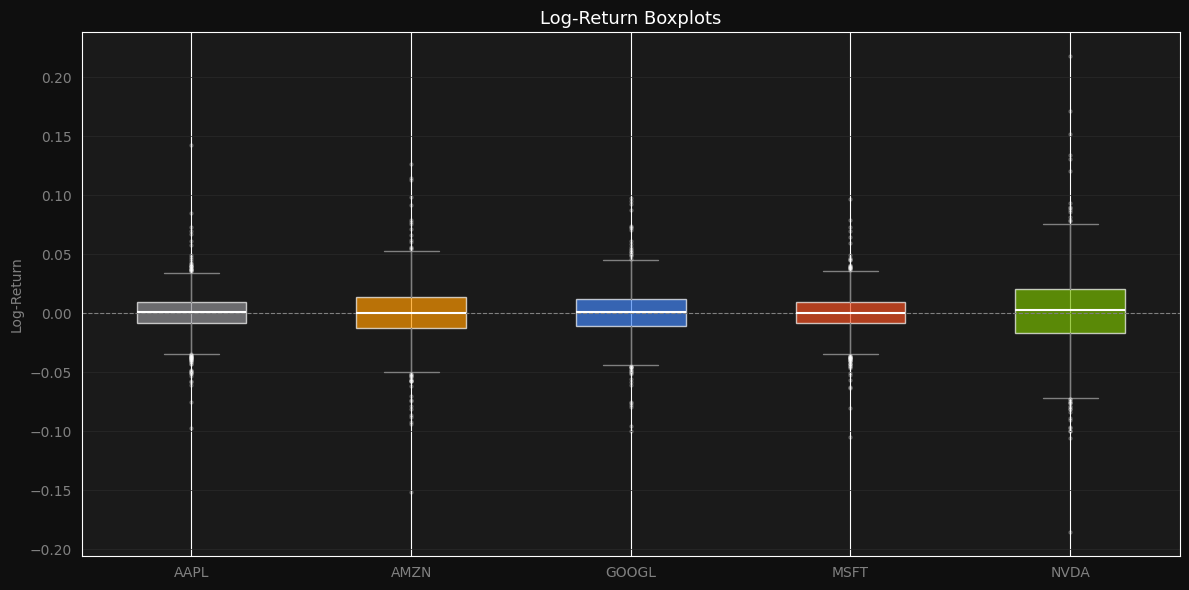

In [13]:
# Figure 2: Boxplots
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

bp = ax.boxplot(
    [log_daily_returns[ticker] for ticker in log_daily_returns.columns],
    labels=log_daily_returns.columns,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=1.5),
    whiskerprops=dict(color="gray"),
    capprops=dict(color="gray"),
    flierprops=dict(marker="o", markersize=2, alpha=0.3)
)

for patch, ticker in zip(bp["boxes"], log_daily_returns.columns):
    patch.set_facecolor(colors[ticker])
    patch.set_alpha(0.7)

for flier, ticker in zip(bp["fliers"], log_daily_returns.columns):
    flier.set_color(colors[ticker])

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Log-Return Boxplots", color="white", fontsize=13)
ax.set_ylabel("Log-Return", color="gray")
ax.tick_params(colors="gray")
ax.grid(axis="y", color="#2A2A2A", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/boxplots.png", facecolor=fig.get_facecolor())
plt.show()

# Part 3: Comparative and Interrelation Analysis

In [14]:
corr_matrix = log_daily_returns.corr()
corr_matrix

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.543856,0.565741,0.581629,0.507704
AMZN,0.543856,1.000000,0.618139,0.639280,0.551190
GOOGL,0.565741,0.618139,1.000000,0.580574,0.517584
MSFT,0.581629,0.639280,0.580574,1.000000,0.613796
NVDA,0.507704,0.551190,0.517584,0.613796,1.000000


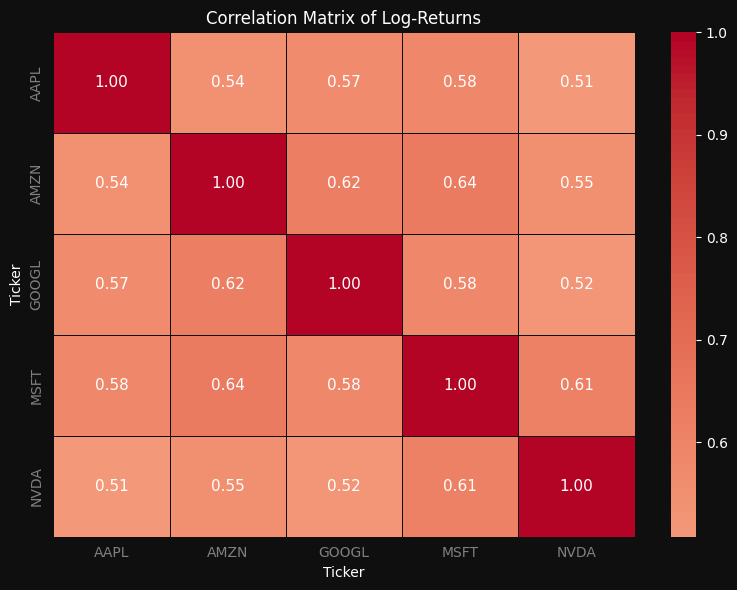

In [15]:
# Figure 1: heatmap

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0F0F0F")
ax.set_facecolor("#1A1A1A")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, linecolor="#0F0F0F", annot_kws={"size": 11, "color": "white"}, ax=ax)

ax.set_title("Correlation Matrix of Log-Returns", color="white")
ax.tick_params(colors="gray")
plt.setp(ax.get_xticklabels(), color="gray")
plt.setp(ax.get_yticklabels(), color="gray")

plt.tight_layout()
plt.savefig("plots/heatmap.png", facecolor=fig.get_facecolor())
plt.show()

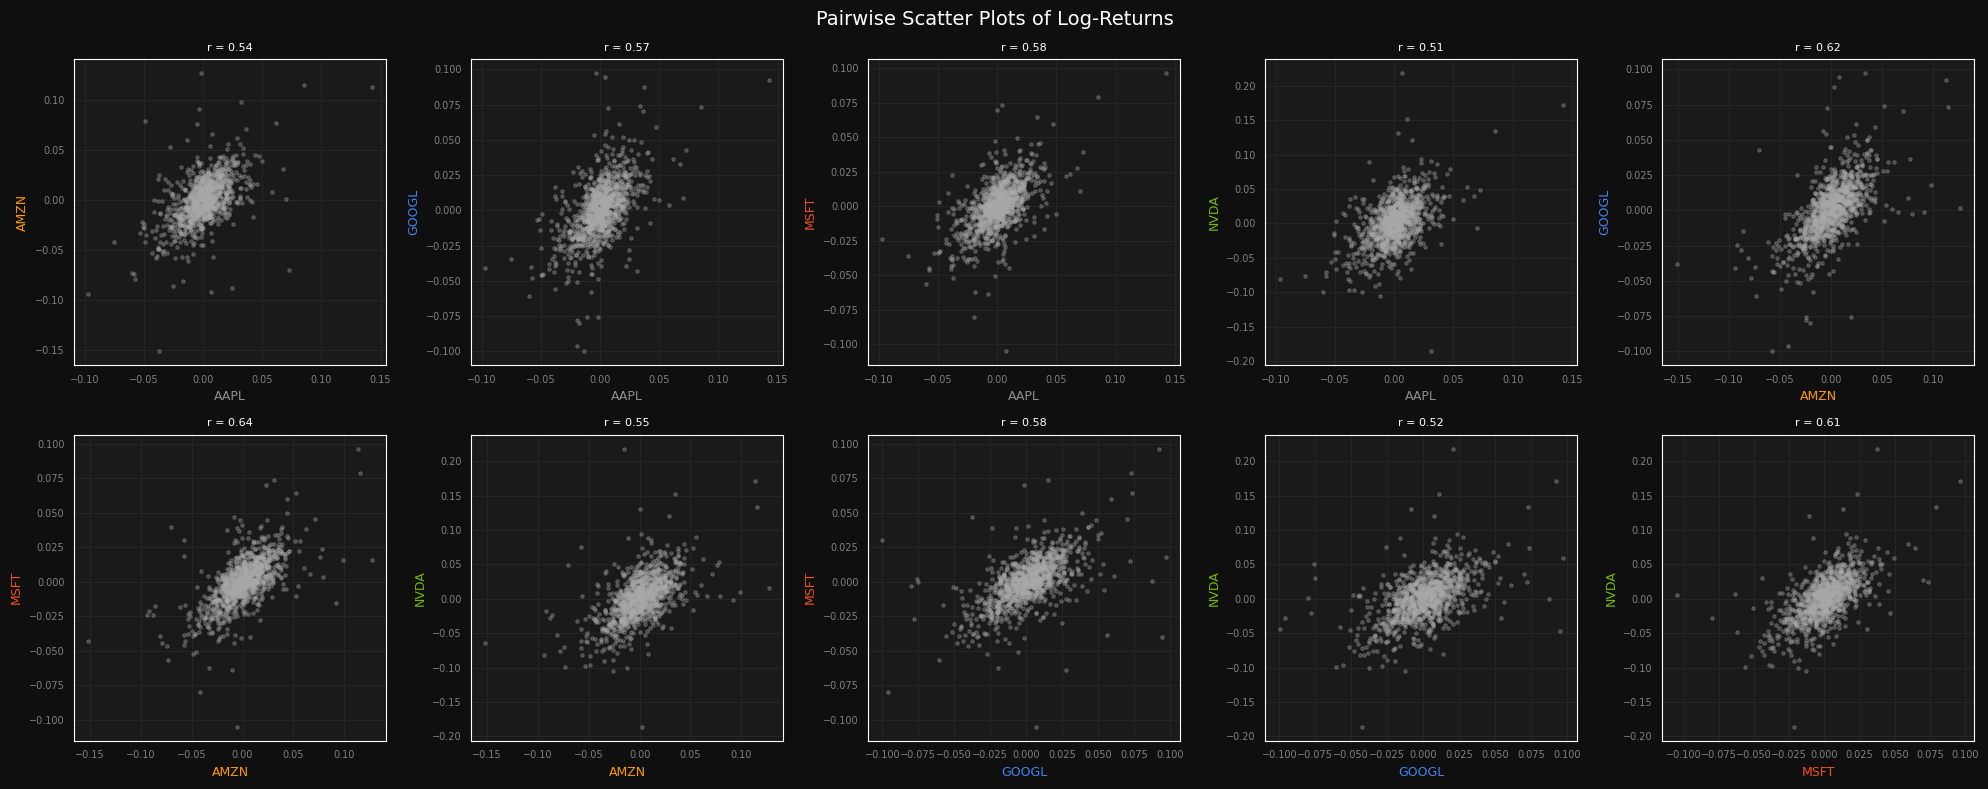

In [16]:
# Figure 2: Scatter Plots
tickers = log_daily_returns.columns.tolist()
pairs = [(tickers[i], tickers[j]) for i in range(len(tickers)) for j in range(i+1, len(tickers))]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.patch.set_facecolor("#0F0F0F")
fig.suptitle("Pairwise Scatter Plots of Log-Returns", color="white", fontsize=14)
axes = axes.flatten()

for ax, (t1, t2) in zip(axes, pairs):
    ax.set_facecolor("#1A1A1A")
    ax.scatter(log_daily_returns[t1], log_daily_returns[t2], alpha=0.3, s=6, color="#AAAAAA")
    ax.set_xlabel(t1, color=colors[t1], fontsize=9)
    ax.set_ylabel(t2, color=colors[t2], fontsize=9)
    ax.tick_params(colors="gray", labelsize=7)
    ax.grid(color="#2A2A2A", linewidth=0.5)

    r = log_daily_returns[t1].corr(log_daily_returns[t2])
    ax.set_title(f"r = {r:.2f}", fontsize=8)

plt.tight_layout()
plt.savefig("plots/scatter_plots.png", facecolor=fig.get_facecolor())
plt.show()


Overall all five stocks are positively correlated among each other. The correlations are close to each other varying from 0.5 to 0.64, with Amazon and Microsoft stocks being the most correlated. This can be explained by the fact that all the stocks are from the same sector, which implies risks associated with a downfall in the sector affecting negatively the whole portfolio.

# Part 4: Hypothesis Testing and Statistical Inference

In [17]:
alpha = 0.05 # significance level for all tests

# Test 1: Is mean log-return significantly different from zero?

for ticker in log_daily_returns.columns:
    if ticker == "NVDA":
        t_stat, p_val = stats.ttest_1samp(log_daily_returns[ticker], 0, alternative="greater")
        alt = "greater"
    else:
        t_stat, p_val = stats.ttest_1samp(log_daily_returns[ticker], 0, alternative="two-sided")
        alt = "two-sided"
    print(f"{ticker}: t={t_stat:.4f}, p={p_val:.4f}, alternative={alt}, reject H0: {p_val < alpha}")

AAPL: t=0.7216, p=0.4707, alternative=two-sided, reject H0: False
AMZN: t=0.5762, p=0.5646, alternative=two-sided, reject H0: False
GOOGL: t=1.4601, p=0.1445, alternative=two-sided, reject H0: False
MSFT: t=0.4101, p=0.6818, alternative=two-sided, reject H0: False
NVDA: t=1.7432, p=0.0408, alternative=greater, reject H0: True


In [18]:
# Test 2: Equal mean returns MSFT vs GOOGL
t_stat, p_val = stats.ttest_ind(log_daily_returns["MSFT"], log_daily_returns["GOOGL"], alternative="two-sided")
print(f"t={t_stat:.4f}, p={p_val:.4f}, reject H0: {p_val < alpha}")

t=-0.8533, p=0.3936, reject H0: False


## Test 1: One-Sample t-test - Is Mean Log-Return Significantly Different from Zero?

**H₀:** μ = 0 (mean log-return is zero)
**H₁:** μ ≠ 0 for AAPL, AMZN, GOOGL, MSFT (two-sided) | μ > 0 for NVDA (one-sided)
**Significance level:** α = 0.05

| Ticker | t-stat | p-value | Reject H₀ |
|--------|--------|---------|-----------|
| AAPL   | 0.7216 | 0.4707  | No        |
| AMZN   | 0.5762 | 0.5646  | No        |
| GOOGL  | 1.4601 | 0.1445  | No        |
| MSFT   | 0.4101 | 0.6818  | No        |
| NVDA   | 1.7432 | 0.0408  | Yes       |

For AAPL, AMZN, GOOGL, and MSFT we fail to reject H₀ - there is insufficient
evidence that their average daily log-return is different from zero at the 5%
significance level.

NVDA is the exception - with p = 0.0408 < 0.05 we reject H₀ in favor of
H₁: μ > 0, meaning NVDA's average daily log-return is significantly positive.

---

## Test 2: Two-Sample t-test - Equal Mean Returns MSFT vs GOOGL

**H₀:** μ_MSFT = μ_GOOGL (equal mean log-returns)
**H₁:** μ_MSFT ≠ μ_GOOGL
**Significance level:** α = 0.05

| t-stat  | p-value | Reject H₀ |
|---------|---------|-----------|
| -0.8533 | 0.3936  | No        |

We fail to reject H₀ - there is no statistically significant difference
between the mean daily log-returns of MSFT and GOOGL.

# Part 5: Modeling

In [19]:
X = log_daily_returns[["AAPL", "AMZN", "GOOGL", "MSFT"]]
y = log_daily_returns["NVDA"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   NVDA   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     217.3
Date:                Fri, 29 May 2026   Prob (F-statistic):          8.38e-137
Time:                        21:49:54   Log-Likelihood:                 2481.0
No. Observations:                1084   AIC:                            -4952.
Df Residuals:                    1079   BIC:                            -4927.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.001      1.621      0.105      -0.000       0.003
AAPL           0.2556      0.056      4.569      0.000       0.146       0.365
AMZN           0.2462      0.046      5.350      0.000       0.156       0.336
GOOGL          0.2114      0.051      4.176      0.000       0.112       0.311
MSFT           0.6638      0.062     10.728      0.000       0.542       0.785
==============================================================================
Omnibus:                      197.506   Durbin-Watson:                   2.112
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2285.072
Skew:                           0.461   Prob(JB):                         0.00
Kurtosis:                      10.053   Cond. No.                         91.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model

We fit an OLS multiple regression to explain NVDA's daily log-returns using

$$r_{NVDA,t} = \alpha + \beta_1 r_{AAPL,t} + \beta_2 r_{AMZN,t} + \beta_3 r_{GOOGL,t} + \beta_4 r_{MSFT,t} + \varepsilon_t$$

### Coefficients

| Variable | Coefficient | p-value | Interpretation |
|----------|-------------|---------|----------------|
| const    | 0.0012      | 0.105   | Not significant — no meaningful daily drift unexplained by peers |
| AAPL     | 0.2556      | 0.000   | A 1% move in AAPL is associated with a 0.26% move in NVDA |
| AMZN     | 0.2462      | 0.000   | A 1% move in AMZN is associated with a 0.25% move in NVDA |
| GOOGL    | 0.2114      | 0.000   | A 1% move in GOOGL is associated with a 0.21% move in NVDA |
| MSFT     | 0.6638      | 0.000   | A 1% move in MSFT is associated with a 0.66% move in NVDA |

All four predictors are highly statistically significant. MSFT has by far the largest coefficient, suggesting it is the strongest  single driver of NVDA's daily moves among the four stocks. This behaviour was expected given the fact that all stocks were from the same sector and positively correlated. This dependence of Nvidia's stock prices on other companies can be explained by the markets perception of the relations of those companies. Amazon, Google, Microsoft  and Apple are making large-scale investments in AI, creating high demand for Nvidia chips. This also explains why the stock return of Microsoft, the largest Nvidia client among the four, has the largest coefficient, marking the most substential impact on the future returns of Nvidia stocks.


### Goodness of Fit
- **R² = 0.446** — the four predictors explain 44.6% of the daily variation in NVDA log-returns
- **F-statistic = 217.3, p = 8.38e-137** — the model as a whole is statistically significant

### Limitations
1) all predictors are same-day returns, so this model explains co-movement, not future returns.
2) the relationship between stocks may be non-linear which is not accounted in the model